In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
df = pd.read_csv("housing.csv")

In [4]:
print(f'Shape of Data: {df.shape}')
df.head(5)

Shape of Data: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [5]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB
None


In a markdown cell, write 2-3 sentences: What is the target variable? What are we
trying to predict? Is this supervised or unsupervised learning? Is this a regression or
classification problem? Why?

In [7]:
#target variable is 'median_house_value'
#We are trying to predict House Price according to multiple independent variables
#This is Supervised Learning: reason is all the columns given are labled as we know there name and there working.
 # The problem is Regression because of only the Number columns are present. One column is ocean_proximity which is string will be converted to one hot encoding   

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df[df['total_bedrooms'].isnull()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47,1256,NaN,570,218,4.3750,161900,NEAR BAY
341,-122.17,37.75,38,992,NaN,732,259,1.6196,85100,NEAR BAY
538,-122.28,37.78,29,5154,NaN,3741,1273,2.5762,173400,NEAR BAY
563,-122.24,37.75,45,891,NaN,384,146,4.9489,247100,NEAR BAY
696,-122.10,37.69,41,746,NaN,387,161,3.9063,178400,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18,3620,NaN,3171,779,3.3409,220500,NEAR OCEAN
20268,-119.18,34.19,19,2393,NaN,1938,762,1.6953,167400,NEAR OCEAN
20372,-118.88,34.17,15,4260,NaN,1701,669,5.1033,410700,<1H OCEAN
20460,-118.75,34.29,17,5512,NaN,2734,814,6.6073,258100,<1H OCEAN


In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

In [12]:
df[['total_bedrooms']] = imputer.fit_transform(df[['total_bedrooms']])

# Plotting Target Variable COlumn

In [13]:
import matplotlib.pyplot as plt

In [14]:
# df['median_house_value'].unique().tolist()

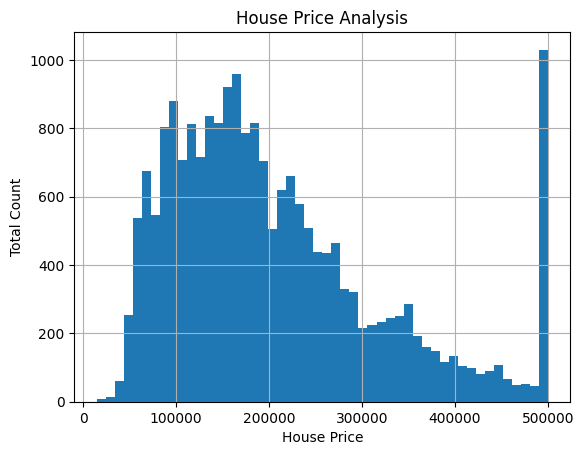

In [15]:
plt.figure()

df['median_house_value'].hist(bins = 50)
plt.xlabel('House Price')
plt.ylabel('Total Count')
plt.title('House Price Analysis')

plt.show()

In [16]:
import numpy as np

df['median_house_value2'] = np.log1p(df['median_house_value'])

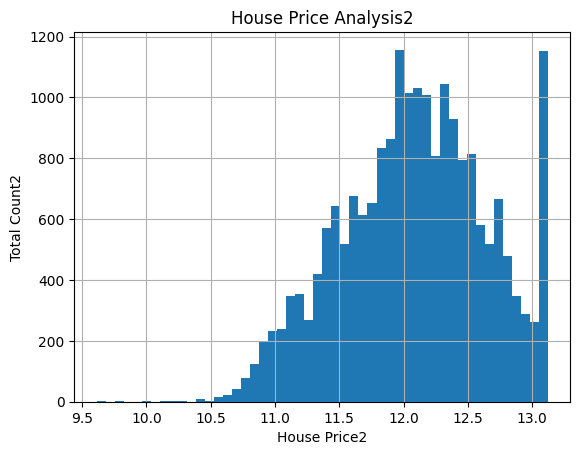

In [17]:
plt.figure()

df['median_house_value2'].hist(bins = 50)
plt.xlabel('House Price2')
plt.ylabel('Total Count2')
plt.title('House Price Analysis2')

plt.show()

# Correlation map:

In [18]:
import seaborn as sns

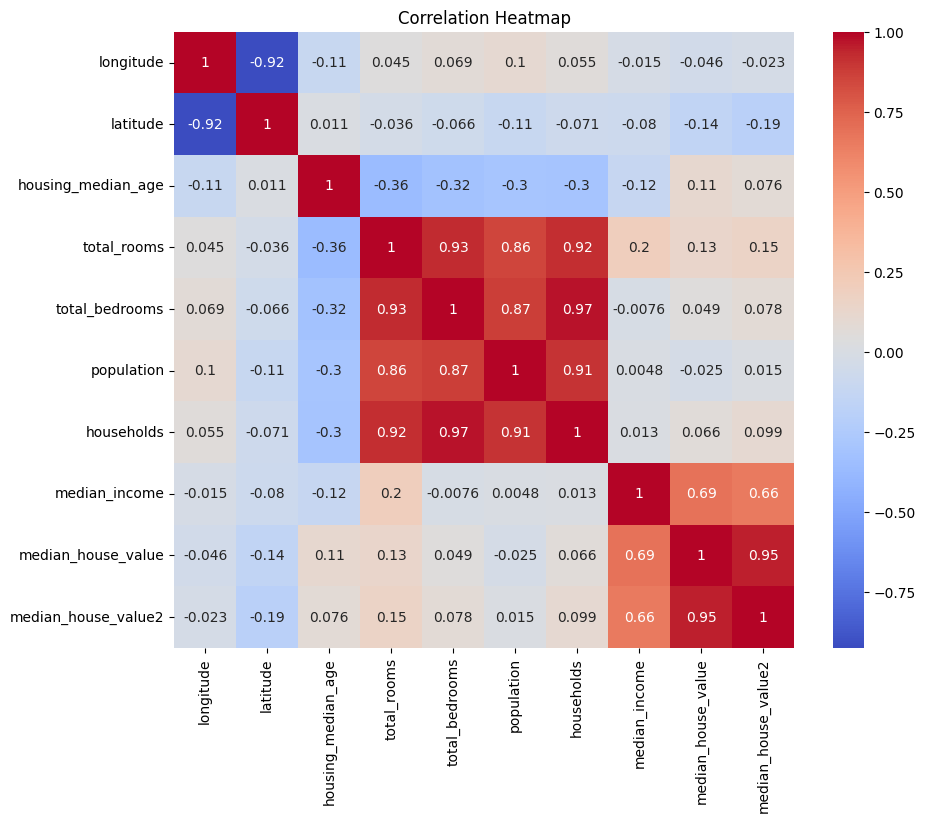

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
#median income, total_rooms



# median_house Value vs median_income

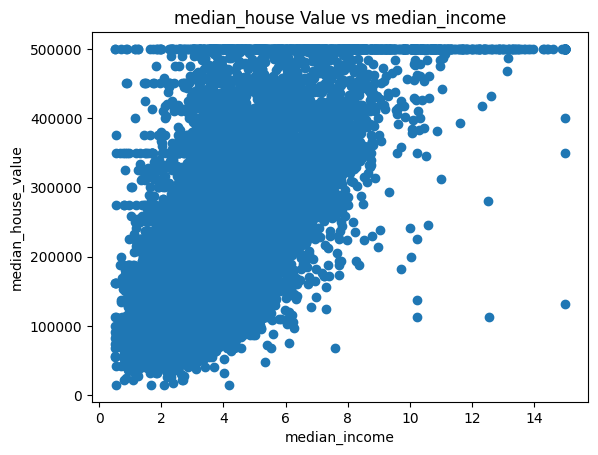

In [21]:
plt.scatter(df['median_income'], df['median_house_value'])
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.title("median_house Value vs median_income")
plt.show()

# Median House Value vs Total Rooms

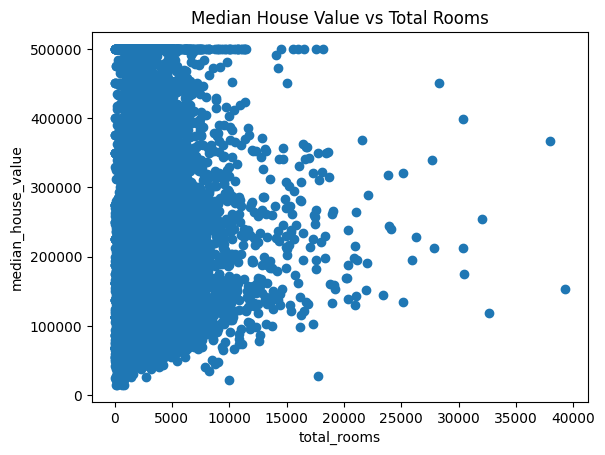

In [22]:
plt.scatter(df['total_rooms'], df['median_house_value'])
plt.xlabel("total_rooms")
plt.ylabel("median_house_value")
plt.title("Median House Value vs Total Rooms")
plt.show()

# outliers

In [23]:
Q1 = df['total_rooms'].quantile(0.25)
Q3 = df['total_rooms'].quantile(0.75)

IQR = Q3 - Q1

In [24]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [25]:
df2 = df[(df['total_rooms'] >= lower_bound) & (df['total_rooms'] <= upper_bound)]

In [26]:
df2['total_rooms']

0         880
2        1467
3        1274
4        1627
5         919
         ... 
20635    1665
20636     697
20637    2254
20638    1860
20639    2785
Name: total_rooms, Length: 19353, dtype: int64

In [27]:
df['total_rooms'] = np.clip(df['total_rooms'], lower_bound, upper_bound)

# Data Preparation

In [28]:
df = pd.get_dummies(df,columns = ['ocean_proximity'])

In [29]:
y = df['median_house_value']
x = df.drop('median_house_value',axis=1)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [32]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(16512, 14) (4128, 14) (16512,) (4128,)


In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

In [35]:
scaler.fit(x_train)
scaler.transform(x_test)

array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [ 0.06097472, -0.23549054,  0.11043502, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-1.42487026,  1.00947776,  1.85617335, ..., -0.01556621,
         2.81178749, -0.3802631 ],
       ...,
       [-1.23041404,  0.78014149, -0.28632369, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-0.08860699,  0.52740357,  0.58654547, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [ 0.60445493, -0.66608108, -0.92113763, ..., -0.01556621,
        -0.35564565, -0.3802631 ]], shape=(4128, 14))

In [36]:
# Fit scaler on the training data
x_train_scaled = scaler.fit_transform(x_train)

# Transform the test data
x_test_scaled = scaler.transform(x_test)

In [37]:
df.columns
# df = df.drop(columns = ['median_house_value2'],index=1 )

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'median_house_value2',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [38]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 14)
(4128, 14)
(16512,)
(4128,)


In [39]:
x_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value2', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [40]:
y_train

14196    103000
8267     382100
17445    172600
14265     93400
2271      96500
          ...  
11284    229200
11964     97800
5390     222100
860      283500
15795    325000
Name: median_house_value, Length: 16512, dtype: int64

In [41]:
x_train_scaled_median_income = x_train['median_income']

In [42]:
x_test_scaled_median_income = x_test['median_income']

In [43]:
x_train_scaled_median_income  = x_train_scaled_median_income.values.reshape(-1,1)

In [44]:
x_test_scaled_median_income

20046    1.6812
3024     2.5313
15663    3.4801
20484    5.7376
9814     3.7250
          ...  
15362    4.6050
16623    2.7266
18086    9.2298
2144     2.7850
3665     3.5521
Name: median_income, Length: 4128, dtype: float64

# Simple Linear Regression

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

In [47]:
model.fit(x_train_scaled_median_income,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
# Print the coefficients (slopes) for each feature
print("Coefficients (slopes):", model.coef_)

# Print the intercept
print("Intercept:", model.intercept_)

Coefficients (slopes): [41933.84939381]
Intercept: 44459.729169078666


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

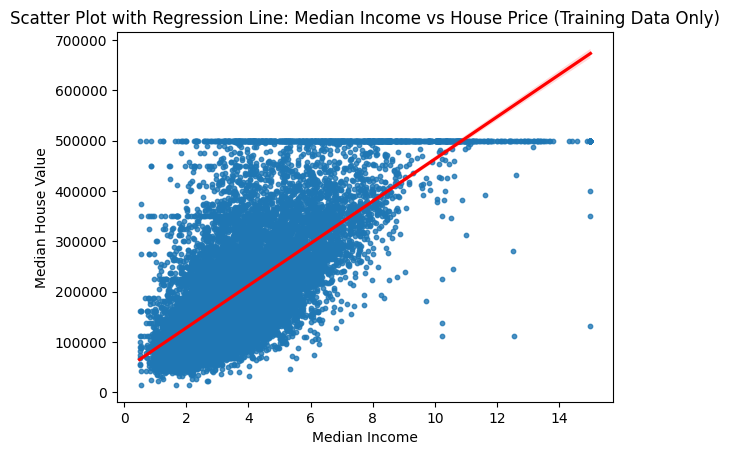

In [77]:
# Scatter plot with regression line using only the training data
sns.regplot(x=x_train_scaled_median_income, y=y_train, scatter_kws={'s':10}, line_kws={'color':'red'})

# Title and labels
plt.title("Scatter Plot with Regression Line: Median Income vs House Price (Training Data Only)")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()



In [78]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [79]:
x_test_scaled_median_income = x_test_scaled_median_income.values.reshape(-1,1)


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [80]:
# Predict on the train set
y_train_pred = model.predict(x_train_scaled_median_income)

ValueError: X has 1 features, but LinearRegression is expecting 14 features as input.

In [81]:
# Predict on the test set
y_test_pred = model.predict(x_test_scaled_median_income)

ValueError: X has 1 features, but LinearRegression is expecting 14 features as input.

In [82]:
# R² score (Training Set)
r2_train = r2_score(y_train, y_train_pred)

# R² score (Testing Set)
r2_test = r2_score(y_test, y_test_pred)

In [83]:
# R² score (Training Set)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# R² score (Testing Set)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))


In [84]:
# Print the results
print(f"R² Score (Training Set): {r2_train}")
print(f"R² Score (Test Set): {r2_test}")
print(f"RMSE (Training Set): {rmse_train}")
print(f"RMSE (Test Set): {rmse_test}")

R² Score (Training Set): 0.9165581972386843
R² Score (Test Set): 0.9135385271859016
RMSE (Training Set): 33398.08136461699
RMSE (Test Set): 33660.049056340664


# Multiple Linear Regression

In [85]:
print('X_train\n',x_train_scaled)
print('\nX_test',x_test_scaled)

X_train
 [[ 1.27258656 -1.3728112   0.34849025 ... -0.01556621 -0.35564565
   2.62975816]
 [ 0.70916212 -0.87669601  1.61811813 ... -0.01556621 -0.35564565
   2.62975816]
 [-0.44760309 -0.46014647 -1.95271028 ... -0.01556621 -0.35564565
   2.62975816]
 ...
 [ 0.59946887 -0.75500738  0.58654547 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [-1.18553953  0.90651045 -1.07984112 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [-1.41489815  0.99543676  1.85617335 ... -0.01556621  2.81178749
  -0.3802631 ]]

X_test [[ 0.28534728  0.1951     -0.28632369 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [ 0.06097472 -0.23549054  0.11043502 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [-1.42487026  1.00947776  1.85617335 ... -0.01556621  2.81178749
  -0.3802631 ]
 ...
 [-1.23041404  0.78014149 -0.28632369 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [-0.08860699  0.52740357  0.58654547 ... -0.01556621 -0.35564565
  -0.3802631 ]
 [ 0.60445493 -0.66608108 -0.92113763 ... -0.01556621 -0.35564565
  -0.3802631 ]]

In [86]:
model = LinearRegression()

In [87]:
model2 = model.fit(x_train_scaled,y_train)

In [88]:
model2

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
# Print the coefficients (slopes) for each feature
print("Coefficients (slopes):", model2.coef_)

# Print the intercept
print("Intercept:", model2.intercept_)

Coefficients (slopes): [  5755.04898091   7221.24378488   7605.09772155  -3377.53319714
   9237.81026767  -8694.05190035   1259.07449612  15108.4420745
 103967.80686501  -3406.82501848   3792.33092807    463.50185548
  -1361.38716664   1058.24561996]
Intercept: 207194.69373788737


In [90]:
pred2 = model2.predict(x_test_scaled)

In [91]:
pred2

array([-40969.44994735, -47086.12580954, 399542.03001421, ...,
       423970.47316283,  50576.44288389, 158926.6747621 ], shape=(4128,))

In [92]:
train_pred = model2.predict(x_train_scaled)

test_pred = model2.predict(x_test_scaled)

In [93]:
train_pred

array([100688.22860688, 365512.85873605, 187410.25358968, ...,
       235914.00568077, 288667.60347444, 322961.12002245], shape=(16512,))

In [94]:
test_pred

array([-40969.44994735, -47086.12580954, 399542.03001421, ...,
       423970.47316283,  50576.44288389, 158926.6747621 ], shape=(4128,))

In [95]:
rmse_y = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_y = np.sqrt(mean_squared_error(y_test, y_test_pred))



In [96]:
rmse_x = np.sqrt(mean_squared_error(x_train, x_train_pred))
rmse_x = np.sqrt(mean_squared_error(x_train, x_test_pred))

NameError: name 'x_train_pred' is not defined

In [97]:
# Train the model with scaled data
model2.fit(x_train_scaled, y_train)

# Predict with the scaled test data
y_test_pred = model2.predict(x_test_scaled)

# Calculate RMSE for the test set
rmse_test = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Print RMSE for the test set
print("RMSE (Test Set):", rmse_test)

RMSE (Test Set): 33398.08136461699


In [98]:
# Train the model with scaled data
model2.fit(x_train_scaled, y_train)

# Predict with the scaled test data
y_test_pred = model2.predict(x_test_scaled)

# Calculate RMSE for the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print RMSE for the test set
print("RMSE (Test Set):", rmse_test)

RMSE (Test Set): 33660.049056340664


In [99]:
# Predict on the training set
y_train_pred = model.predict(x_train_scaled)

# Predict on the test set
y_test_pred = model.predict(x_test_scaled)

# R² Score (Training Set)
r2_train = r2_score(y_train, y_train_pred)

# R² Score (Test Set)
r2_test = r2_score(y_test, y_test_pred)

# RMSE (Training Set)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# RMSE (Test Set)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print the results
print(f"R² Score (Training Set): {r2_train}")
print(f"R² Score (Test Set): {r2_test}")
print(f"RMSE (Training Set): {rmse_train}")
print(f"RMSE (Test Set): {rmse_test}")

R² Score (Training Set): 0.9165581972386843
R² Score (Test Set): 0.9135385271859016
RMSE (Training Set): 33398.08136461699
RMSE (Test Set): 33660.049056340664


In [100]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# R2 Score Train
r2_train = r2_score(y_train, y_pred_train)

# R2 Score Test
r2_test = r2_score(y_test, y_pred_test)

#predict on training data:
y_pred_train = model2.predict(x_train_scaled)

#predict on Test data
y_pred_test = model2.predict(x_test_scaled)

# Root Mean Squared Error on Training Data
rmse_train = np.sqrt(mean_squared_error(y_train,y_pred_train))

# Root Mean Squared Error on Test Data
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))



NameError: name 'y_pred_train' is not defined

# Compairson of Simple Vs Multilple Regression

## Single Linear Regression:

###### R² Score (Training Set): 0.4765692645350246
###### R² Score (Test Set): 0.4601947854291476
###### RMSE (Training Set): 83696.85486555003
###### RMSE (Test Set): 83897.71135564751

## Multiple Linear Regression:

###### R² Score (Training Set): 0.6459380468900757
###### R² Score (Test Set): 0.6402704316419567
###### RMSE (Training Set): 68836.55993995647
###### RMSE (Test Set): 68488.81378839484

In [102]:
# Print the results
print(f"R² Score (Training Set): {r2_train}")
print(f"R² Score (Test Set): {r2_test}")
print(f"RMSE (Training Set): {rmse_train}")
print(f"RMSE (Test Set): {rmse_test}")

R² Score (Training Set): 0.9165581972386843
R² Score (Test Set): 0.9135385271859016
RMSE (Training Set): 33398.08136461699
RMSE (Test Set): 33660.049056340664


In [122]:
x_train_scaled, x_test_scaled, y_train, y_test

(array([[ 1.27258656, -1.3728112 ,  0.34849025, ..., -0.01556621,
         -0.35564565,  2.62975816],
        [ 0.70916212, -0.87669601,  1.61811813, ..., -0.01556621,
         -0.35564565,  2.62975816],
        [-0.44760309, -0.46014647, -1.95271028, ..., -0.01556621,
         -0.35564565,  2.62975816],
        ...,
        [ 0.59946887, -0.75500738,  0.58654547, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.18553953,  0.90651045, -1.07984112, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.41489815,  0.99543676,  1.85617335, ..., -0.01556621,
          2.81178749, -0.3802631 ]], shape=(16512, 14)),
 array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [ 0.06097472, -0.23549054,  0.11043502, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.42487026,  1.00947776,  1.85617335, ..., -0.01556621,
          2.81178749, -0.3802631 ],
        ...,
        [-1.23041404,  0.78014149, 

14196    103000
8267     382100
17445    172600
14265     93400
2271      96500
          ...  
11284    229200
11964     97800
5390     222100
860      283500
15795    325000
Name: median_house_value, Length: 16512, dtype: int64

In [109]:
y_test

20046     47700
3024      45800
15663    500001
20484    218600
9814     278000
          ...  
15362    263300
16623    266800
18086    500001
2144      72300
3665     151500
Name: median_house_value, Length: 4128, dtype: int64

In [124]:
x_train_scaled,x_test_scaled,y_train,y_test

(array([[ 1.27258656, -1.3728112 ,  0.34849025, ..., -0.01556621,
         -0.35564565,  2.62975816],
        [ 0.70916212, -0.87669601,  1.61811813, ..., -0.01556621,
         -0.35564565,  2.62975816],
        [-0.44760309, -0.46014647, -1.95271028, ..., -0.01556621,
         -0.35564565,  2.62975816],
        ...,
        [ 0.59946887, -0.75500738,  0.58654547, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.18553953,  0.90651045, -1.07984112, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.41489815,  0.99543676,  1.85617335, ..., -0.01556621,
          2.81178749, -0.3802631 ]], shape=(16512, 14)),
 array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [ 0.06097472, -0.23549054,  0.11043502, ..., -0.01556621,
         -0.35564565, -0.3802631 ],
        [-1.42487026,  1.00947776,  1.85617335, ..., -0.01556621,
          2.81178749, -0.3802631 ],
        ...,
        [-1.23041404,  0.78014149, 

.

# bb) Ridge Regression (alpha = 1.0)

In [110]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso

In [111]:
ridge = Ridge(alpha = 1.0)
ridge.fit(x_train_scaled,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [114]:
#prediction
y_train_pred_ridge = ridge.predict(x_train_scaled)

y_test_pred_ridge = ridge.predict(x_test_scaled)

In [117]:
#r2 Score
r2_train_ridge  = r2_score(y_train,y_train_pred_ridge)
r2_test_ridge  = r2_score(y_test,y_test_pred_ridge)

print(r2_train_ridge)
print(r2_test_ridge)

0.9165581876459687
0.913540803371602


# cc) Lasso Regression (alpha = 0.1)

In [ ]:
lasso = Lasso(alpha=0.1)

lasso.fit(x_train_scaled, y_train)

In [120]:



# Predictions
y_train_pred_lasso = lasso.predict(x_train_scaled)
y_test_pred_lasso = lasso.predict(x_test_scaled)

# R2
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)


In [121]:
print("Lasso Train R2:", r2_train_lasso)
print("Lasso Test R2:", r2_test_lasso)


Lasso Train R2: 0.9165581971606372
Lasso Test R2: 0.9135385244743066


# dd) Bar Chart (Compare Coefficients)

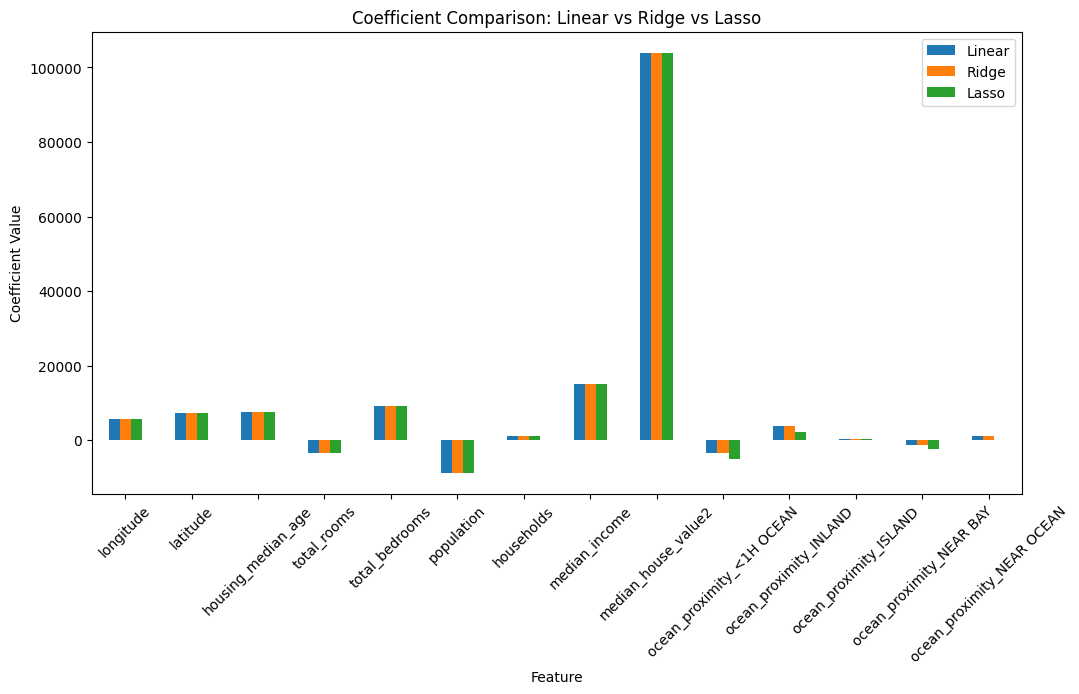

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Linear': model.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

coef_df.set_index('Feature').plot(kind='bar', figsize=(12,6))

plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()

In [136]:
print(lasso.coef_)

[  5751.86959227   7217.89957364   7604.87721821  -3376.67435509
   9238.24915217  -8693.02603086   1256.84062778  15108.17288325
 103967.47469985  -4989.34166781   2311.5197727     413.82637481
  -2366.75832299      0.        ]


Lasso regression can set some coefficients exactly to zero, effectively performing feature selection. If any coefficients are zero, it means those features are not contributing to the model and are removed. This makes sense because Lasso penalizes less important features more strongly, reducing their impact or eliminating them completely.

In [141]:
for feature, coef in zip(x_test.columns, lasso.coef_):
    if coef == 0:
        print(feature)

households


# ff) Try different alpha values

In [138]:
import numpy as np

alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = []
lasso_scores = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(x_train_scaled, y_train)
    ridge_scores.append(ridge.score(x_test_scaled, y_test))

    lasso = Lasso(alpha=a)
    lasso.fit(x_train_scaled, y_train)
    lasso_scores.append(lasso.score(x_test_scaled, y_test))

# Create table
results = pd.DataFrame({
    'alpha': alphas,
    'Ridge_R2': ridge_scores,
    'Lasso_R2': lasso_scores
})

print(results)

C:\PythonScript\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.427e+11, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


    alpha  Ridge_R2  Lasso_R2
0    0.01  0.913539  0.913539
1    0.10  0.913539  0.913539
2    1.00  0.913541  0.913538
3   10.00  0.913560  0.913536
4  100.00  0.913636  0.913569


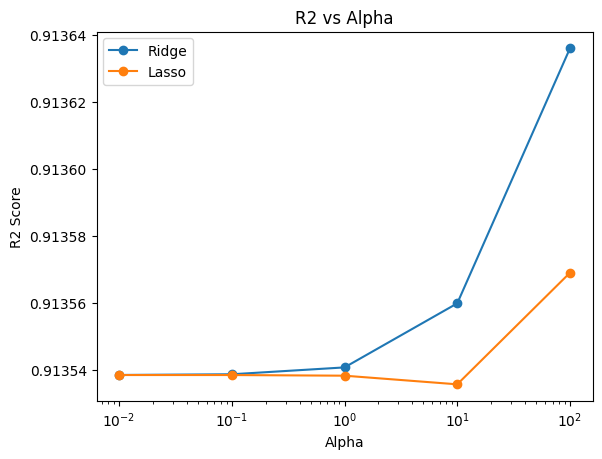

In [139]:
plt.plot(alphas, ridge_scores, label='Ridge', marker='o')
plt.plot(alphas, lasso_scores, label='Lasso', marker='o')

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("R2 vs Alpha")
plt.legend()
plt.show()

# PART B: CLASSIFICATION

In [142]:
df2 = pd.read_csv('heart.csv')

In [143]:
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [145]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [155]:
x = df2.drop( columns=['target'])

y = df2.iloc[:,[-1]]

In [160]:
print("\nClass Distribution:\n")
print(df2['target'].value_counts())


Class Distribution:

target
1    526
0    499
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import test_train_split(df2)
x_train,y_train,x_test,y_test

In [163]:
df2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [165]:
df2.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Countplot (Target Distribution)

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

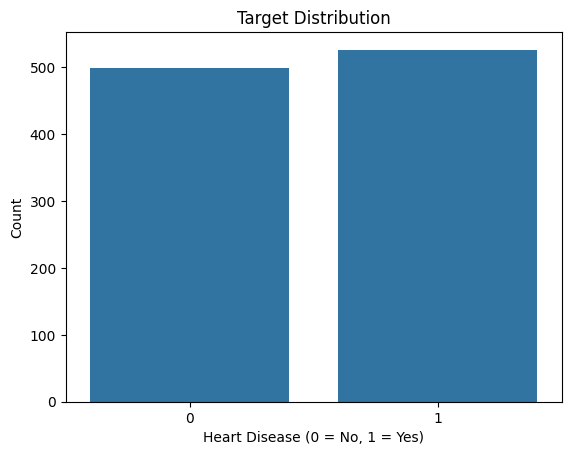

In [180]:
sns.countplot(x='target', data=df2)

plt.title("Target Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

# Correlation Heatmap

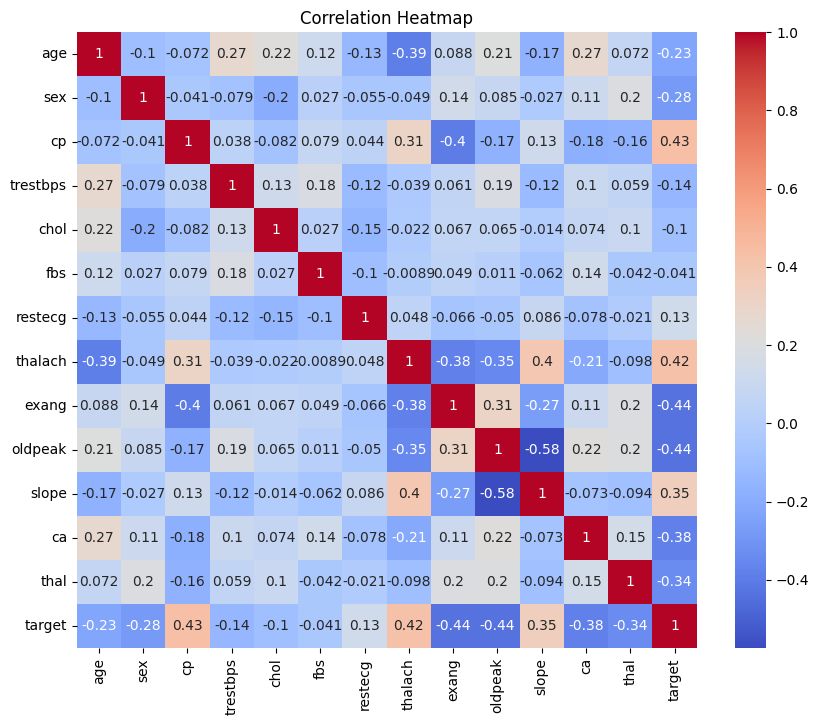

In [181]:
plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='target', ylabel='thalach'>

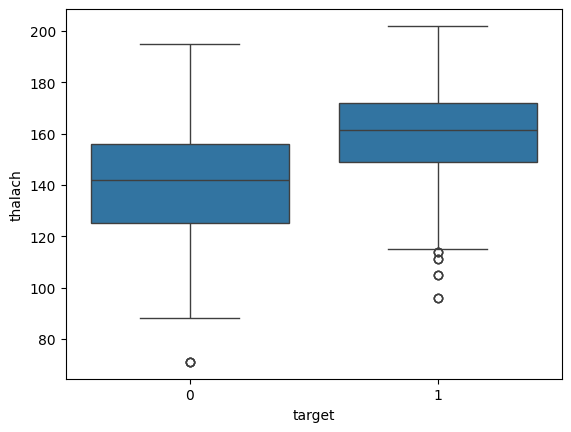

In [184]:
sns.boxplot(x='target',y='thalach',data=df2)

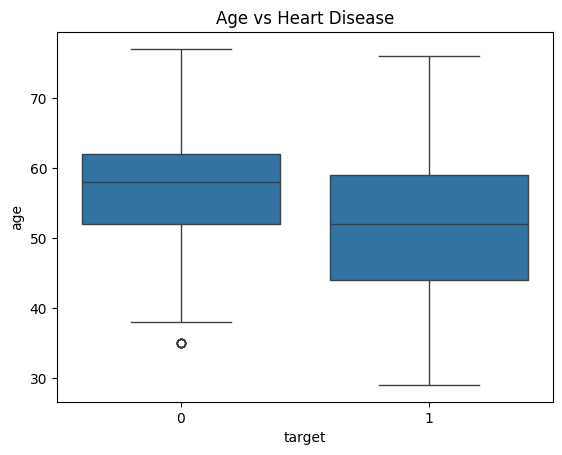

In [186]:
sns.boxplot(x='target', y='age', data=df2)
plt.title("Age vs Heart Disease")
plt.show()

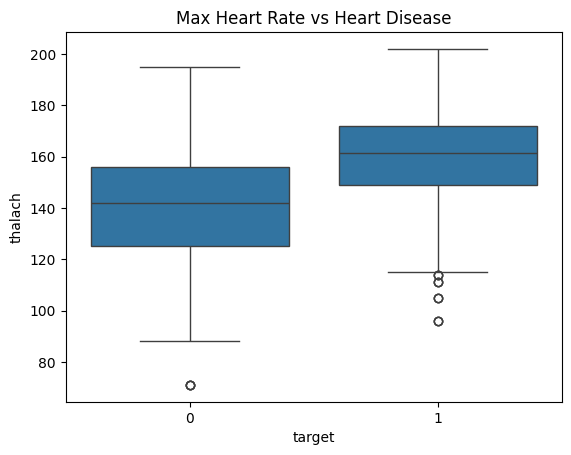

In [187]:
sns.boxplot(x='target', y='thalach', data=df2)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

# 10 Data Preparation & Model Training

In [192]:
x = df2.drop( columns=['target'])

y = df2.iloc[:,[-1]]

In [195]:
from sklearn.model_selection import train_test_split

In [200]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [199]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform on training data, then transform test data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [202]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train_scaled, y_train)

C:\PythonScript\env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [203]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

     Feature  Coefficient
2         cp     0.885835
7    thalach     0.652826
10     slope     0.343605
6    restecg     0.140804
0        age    -0.006734
5        fbs    -0.062685
3   trestbps    -0.320053
8      exang    -0.420235
4       chol    -0.447276
12      thal    -0.656856
9    oldpeak    -0.765406
1        sex    -0.835665
11        ca    -0.847522


In [204]:
print('hello world')

hello world
